The SABR (Stochastic Alpha, Beta, Rho) model is a stochastic volatility model used to capture the volatility smile observed in the market.

The model is defined by two linked stochastic differential equations:
- Forward Rate ($F$): $dF_t = \alpha_t F_t^\beta dW_t^1$
- Volatility ($\alpha$): $d\alpha_t = \nu \alpha_t dW_t^2$
- Correlation: $dW_t^1 dW_t^2 = \rho dt$

where the forward rate $F$ is related to the current stock (spot) price $S$ with risk-free rate $r$, dividend yield $q$, and time to expiry $T$ (in years) as
$$F = S \cdot e^{(r - q)T}$$

The Parameters:
- $\alpha$: The initial volatility level ($\alpha_0$) (implied by the at-the-money volatility, shifts the curve up/down).
- $\beta$: The exponent for the forward rate (0 for normal, 1 for log-normal (Black-Scholes style), 0.5 for CIR).
- $\rho$: Correlation between the rate and its volatility (controls the "skew" or slope).
- $\nu$: Volatility of volatility (controls the convexity of the "smile").

In [87]:
import yfinance as yf
import pandas as pd
import numpy as np
import random
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import interp1d

First we extract options data for an instrument from yfinance, and also calculate historical variance standard deviation to be used for comparing with Black-Scholes (BS) model.

In [88]:
def calculate_forward_price(S, T, r, q=0.015):
    """
    S: Spot Price (from yfinance)
    T: Time to expiry (years)
    r: Risk-free rate (e.g., 0.04 for 4%)
    q: Dividend yield (e.g., 0.015 for 1.5% for SPY)
    """
    return S * np.exp((r - q) * T)

def get_live_sabr_data(ticker_symbol, expiration_index=1):
    ticker = yf.Ticker(ticker_symbol)

    # Get current price (Forward price F approximation)
    S = ticker.fast_info['lastPrice']

    # Get available expiration dates and pick one (default is the second available)
    expiries = ticker.options
    target_expiry = expiries[expiration_index]

    # Calculate Time to Maturity (T) in years
    days_to_expiry = (pd.to_datetime(target_expiry) - pd.Timestamp.now()).days
    T = max(days_to_expiry / 365.0, 1/365.0)

    # Get the option chain
    opt = ticker.option_chain(target_expiry)
    calls = opt.calls

    # Clean data: Filter for liquidity (openInterest > 0) and remove zero IVs
    df = calls[(calls['openInterest'] > 10) & (calls['impliedVolatility'] > 0.01)].copy()

    # We only need strikes and market implied volatilities
    market_strikes = df['strike'].values
    market_vols = df['impliedVolatility'].values

    return S, T, market_strikes, market_vols, target_expiry

# Example: Get data for a stock
ticker_symbol = "SPY" # Try GLD
expiration_index=15

ticker = yf.Ticker(ticker_symbol)
S, T, strikes, vols, date = get_live_sabr_data(ticker_symbol, expiration_index) # Use expiration date at least 1.5 months later (i.e., expiration index at least 10 for SPY) for decent data
r = 0.045
q = 0.015
F = calculate_forward_price(S, T, r, q)

# Calculate Historical Volatility (Constant Vol Baseline)
hist_data = ticker.history(period="1y")
# log_returns = np.log(hist_data['Close'] / hist_data['Close'].shift(1)) # One can use log returns instead of simple returns due to their additive properties
# const_vol_baseline = log_returns.std() * np.sqrt(252)
returns = hist_data['Close'].pct_change() # One can use 'Adj Close' instead of 'Close' to account for dividends and stock splits whenever possible
const_vol_baseline = returns.std() * np.sqrt(252) # To make the data annualized from daily

opt_chain = ticker.option_chain(date).calls

# Filter for liquid strikes near the money (within 10%)
mask = (opt_chain['strike'] > F * 0.9) & (opt_chain['strike'] < F * 1.1) & (opt_chain['openInterest'] > 100)
market_data = opt_chain[mask]
available_strikes = market_data['strike'].values

print(f"Data for {date}: F={F:.2f}, T={T:.3f} years, {len(strikes)} strikes found.")

Data for 2026-05-15: F=697.03, T=0.214 years, 105 strikes found.


At the industry level, the forward price is also calulated using the Put-Call Parity. The strike price at which put and call options have same price is the forward price.

In [89]:
def get_implied_forward(ticker_symbol, expiration_index):
    ticker = yf.Ticker(ticker_symbol)

    # Get the specific expiry date
    expiry = ticker.options[expiration_index]
    opt = ticker.option_chain(expiry)

    calls = opt.calls[['strike', 'lastPrice']].rename(columns={'lastPrice': 'call_price'})
    puts = opt.puts[['strike', 'lastPrice']].rename(columns={'lastPrice': 'put_price'})

    # Merge calls and puts on strike price
    df = pd.merge(calls, puts, on='strike').dropna()

    # Calculate the price difference
    df['diff'] = df['call_price'] - df['put_price'] # We want to find where diff = 0.

    # Since we have discrete strikes, we use interpolation.
    if (df['diff'] > 0).any() and (df['diff'] < 0).any():

        # Create an interpolation function: Strike as a function of Price Difference
        df = df.sort_values('diff') # Sort values to ensure a clean interpolation
        f_interp = interp1d(df['diff'], df['strike'], kind='linear', fill_value="extrapolate")

        implied_f = float(f_interp(0))
        return implied_f, expiry
    else:
        # Fallback to the strike with the minimum absolute difference
        idx = df['diff'].abs().idxmin()
        return df.loc[idx, 'strike'], expiry

# --- Execution ---
f_implied, date = get_implied_forward(ticker_symbol, expiration_index)

print(f"Ticker: {ticker_symbol}")
print(f"Expiry Date: {date}")
print(f"Forward Price from Put-Call Parity: {f_implied:.2f}")
print(f"Forward Price from Spot price: {F:.2f}")
F = f_implied

Ticker: SPY
Expiry Date: 2026-05-15
Forward Price from Put-Call Parity: 696.01
Forward Price from Spot price: 697.03


Since the forward price is similar in both cases, we will use the one coming from the Put-Call Parity.

Using singular perturbation, we get the closed-form approximation for $\sigma_\text{Black}$.

$\sigma_\text{Black}(F,K) = \frac{\alpha}{(FK)^{\frac{1-\beta}{2}} \left\{ 1 + \frac{(1-\beta)^2}{24} \ln^2 \frac{F}{K} + \frac{(1-\beta)^4}{1920}\ln^4 \frac{F}{K} + \cdots \right\}} \cdot \frac{z}{x(z)} \cdot \{ 1 + \left[ \frac{(1-\beta)^2}{24} \frac{\alpha^2}{(FK)^{1-\beta}} + \frac{1}{4}\frac{\alpha \beta \rho \nu}{(FK)^{\frac{1-\beta}{2}}} + \frac{2-3\rho^2}{24}\nu^2\right] T + \cdots$

Here,

$z = \frac{\nu}{\alpha} (FK)^{\frac{1-\beta}{2}} \ln \frac{F}{K}$,

$x(z) = \ln \frac{\sqrt{1 - 2\rho z + z^2} + z - \rho}{1 - \rho}$,

$T$ is the time to expiry.

Note that the formula of $\sigma_\text{Black}$ is slightly different for Normal (Bachelier) Volatility version which is usually used for modelling interest rates, as they can go negative. The formula given above uses the Log-normal (Black) Volatility version, which is the industry standard for Equities, FX (like USDINR), and Commodities.

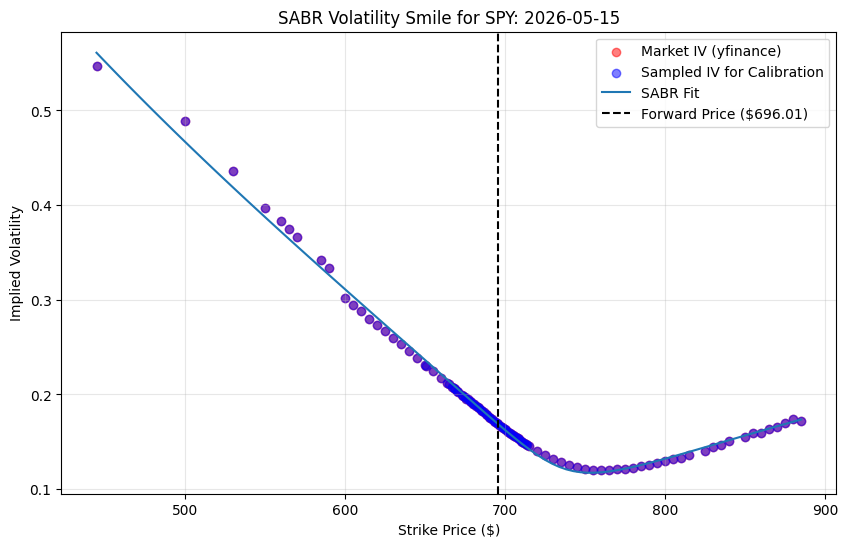

Parameters: alpha = 115.94, beta = 0.00, rho = -0.77, nu = 2.36, sample error: 0.002640, population error: 0.002640


In [90]:
def sabr_vol(F, K, T, alpha, beta, rho, nu):
    V = (F * K) ** ((1 - beta) / 2)
    log_FK = np.log(F / K)

    z = (nu / alpha) * V * log_FK

    # x(z) function
    x_z = np.log((np.sqrt(1 - 2 * rho * z + z**2) + z - rho) / (1 - rho))

    # Core Hagan approximation components
    A = alpha / (V * (1 + ((1 - beta)**2 / 24) * log_FK**2 + ((1 - beta)**4 / 1920) * log_FK**4))
    B = 1 + (((1 - beta)**2 / 24) * (alpha**2 / V**2) +
             (1/4) * (alpha * beta * rho * nu  / V) +
             ((2 - 3 * rho**2) / 24) * nu**2) * T

    if F == K:
        return A * B
    else:
        return A * (z / x_z) * B

def calibrate_sabr(market_vols, strikes, F, T):
    # objective function: minimize Sum of Squared Errors (SSE)
    def objective(params):
        alpha, beta, rho, nu = params
        # Constraints: alpha > 0, nu > 0, -1 < rho < 1
        if alpha <= 0 or nu <= 0 or abs(rho) >= 1:
            return 1e10

        model_vols = [sabr_vol(F, K, T, alpha, beta, rho, nu) for K in strikes]
        return np.sum((np.array(market_vols) - np.array(model_vols))**2)

    initial_guess = [0.01, 0.5, -0.5, 0.1] # might need to change the initial guess if we get horizontal line as the fit
    result = minimize(objective, initial_guess, method='L-BFGS-B', bounds=[(1e-6, 1e10), (0, 1), (-1, 1), (1e-6, 1e10)]) # Try Nelder-Mead if we get a flat line
    return result

# Generate a sample of market data for calibration in case of outliers or huge data size
# Combine strikes and vols, then sample
combined_data = list(zip(strikes, vols))
num_calibration_samples = min(len(combined_data), 1e10) # Ensure we don't sample more than available
sampled_data = random.sample(combined_data, num_calibration_samples)
sampled_strikes = np.array([d[0] for d in sampled_data])
sampled_vols = np.array([d[1] for d in sampled_data])

# Calibrate with sampled data
calibration_result = calibrate_sabr(sampled_vols, sampled_strikes, F, T)
params = calibration_result.x
sampled_error = calibration_result.fun
alpha_cal, beta_cal, rho_cal, nu_cal = params

# Calculate error for the entire population using calibrated parameters
full_market_model_vols = [sabr_vol(F, K, T, alpha_cal, beta_cal, rho_cal, nu_cal) for K in strikes]
full_market_error = np.sum((np.array(vols) - np.array(full_market_model_vols))**2)

# Generate the fitted smile (using the full range of strikes for visualization)
plot_strikes = np.linspace(min(strikes), max(strikes), 100)
sabr_fitted_vols = [sabr_vol(F, K, T, alpha_cal, beta_cal, rho_cal, nu_cal) for K in plot_strikes]

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(strikes, vols, color='red', alpha=0.5, label='Market IV (yfinance)')
plt.scatter(sampled_strikes, sampled_vols, color='blue', alpha=0.5, label='Sampled IV for Calibration')
plt.plot(plot_strikes, sabr_fitted_vols, label=f'SABR Fit')
plt.axvline(F, color='black', linestyle='--', label=f'Forward Price (${F:.2f})')
plt.title(f"SABR Volatility Smile for {ticker_symbol}: {date}")
plt.xlabel("Strike Price ($)")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f'Parameters: alpha = {alpha_cal:.2f}, beta = {beta_cal:.2f}, rho = {rho_cal:.2f}, nu = {nu_cal:.2f}, sample error: {sampled_error:.6f}, population error: {full_market_error:.6f}')

- $\alpha$ is the ATM volatility.
- $\rho$ is negative as expected.
- Positive value of $\nu$ shows that volatility itself is volatile and not constant like Black-Scholes assumption.

- For equities and commodities (like GLD), we have mirror image since, the dropping price creates more fear and hence volatility in case of equities, as opposed to commodities.
- On the other hand, FX Swaptions give a symmetric volatility smile. (Difficult to fetch FX swaptions data from yfinance as they are usually traded Over-the-Counter (OTC) or at specific exchanges that do not give access to yfinance).

Now we compare option prices for certain options using SABR model and Black-Scholes model (that uses a constant volatility—a historical average).  

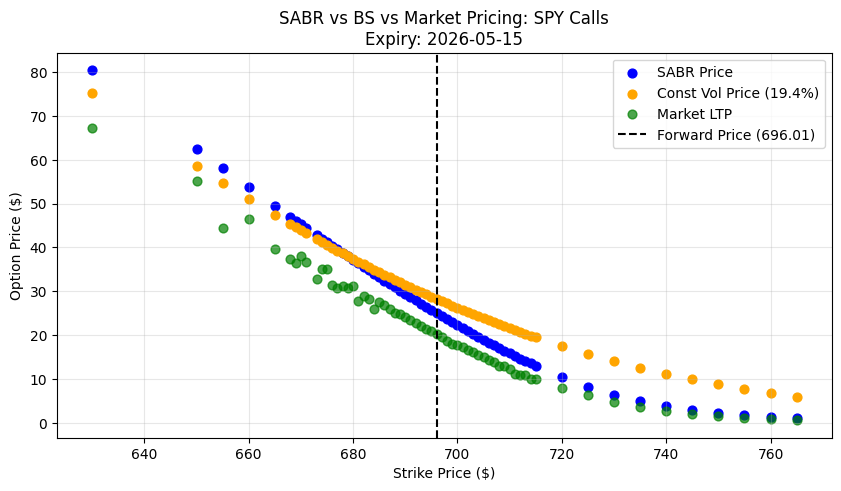

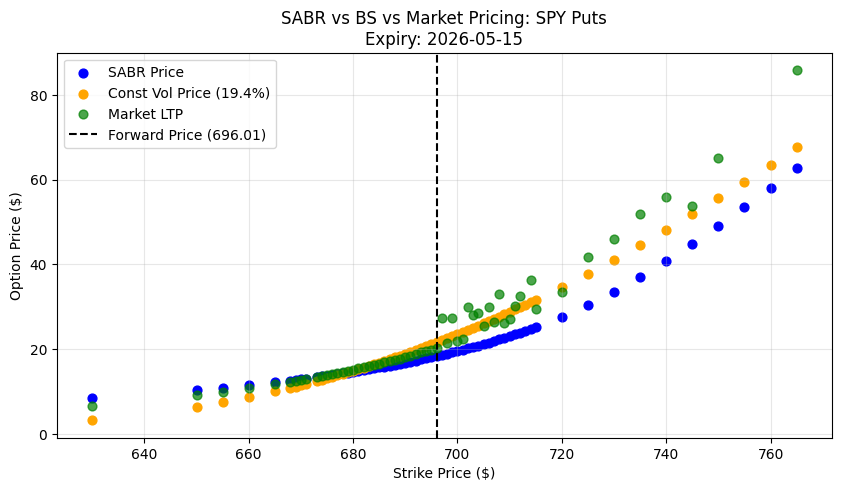

In [91]:
# Closed form formula for BS option pricing
def black_scholes_price(S, K, T, r, sigma, option_type='call'):
    if T <= 0 or sigma <= 0: return max(0, S - K) if option_type == 'call' else max(0, K - S)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type.lower() == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Calculating call option prices
sabr_call_prices = []
const_vol_call_prices = []

# Fetch market call data for comparison
market_calls = ticker.option_chain(date).calls
market_calls_filtered = market_calls[market_calls['strike'].isin(available_strikes)]
# Ensure the market prices are aligned with the available_strikes order
market_calls_prices = market_calls_filtered.set_index('strike').reindex(available_strikes)['lastPrice'].values

for K in available_strikes:
    vol_s = sabr_vol(F, K, T, alpha_cal, beta_cal, rho_cal, nu_cal)
    sabr_call_prices.append(black_scholes_price(F, K, T, r, vol_s, 'call'))
    const_vol_call_prices.append(black_scholes_price(F, K, T, r, const_vol_baseline, 'call'))

sabr_call_prices = np.array(sabr_call_prices)
const_vol_call_prices = np.array(const_vol_call_prices)

# Visualization
plt.figure(figsize=(10, 5))
plt.scatter(available_strikes, sabr_call_prices, color='blue', label='SABR Price', s=40)
plt.scatter(available_strikes, const_vol_call_prices, color='orange', label=f'Const Vol Price ({const_vol_baseline:.1%})', s=40)
plt.scatter(available_strikes, market_calls_prices, color='green', label='Market LTP', marker='o', s=40, alpha=0.7)
plt.axvline(F, color='black', linestyle='--', label=f'Forward Price ({F:.2f})')
plt.title(f"SABR vs BS vs Market Pricing: {ticker_symbol} Calls\nExpiry: {date}")
plt.xlabel("Strike Price ($)")
plt.ylabel("Option Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print('\n')
# Calculating put option prices
sabr_put_prices = []
const_vol_put_prices = []

# Fetch market put data for comparison
market_puts = ticker.option_chain(date).puts
market_puts_filtered = market_puts[market_puts['strike'].isin(available_strikes)]
market_puts_prices = market_puts_filtered.set_index('strike').reindex(available_strikes)['lastPrice'].values

for K in available_strikes:
    vol_s = sabr_vol(F, K, T, alpha_cal, beta_cal, rho_cal, nu_cal)
    sabr_put_prices.append(black_scholes_price(F, K, T, r, vol_s, 'put'))
    const_vol_put_prices.append(black_scholes_price(F, K, T, r, const_vol_baseline, 'put'))

sabr_put_prices = np.array(sabr_put_prices)
const_vol_put_prices = np.array(const_vol_put_prices)

# Visualization
plt.figure(figsize=(10, 5))
plt.scatter(available_strikes, sabr_put_prices, color='blue', label='SABR Price', s=40)
plt.scatter(available_strikes, const_vol_put_prices, color='orange', label=f'Const Vol Price ({const_vol_baseline:.1%})', s=40)
plt.scatter(available_strikes, market_puts_prices, color='green', label='Market LTP', marker='o', s=40, alpha=0.7)
plt.axvline(F, color='black', linestyle='--', label=f'Forward Price ({F:.2f})')
plt.title(f"SABR vs BS vs Market Pricing: {ticker_symbol} Puts\nExpiry: {date}")
plt.xlabel("Strike Price ($)")
plt.ylabel("Option Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We are seeing that OTM strikes have higher BS price than the SABR price, this is because the historical volatility is higher than usual and SABR model expects it to calm down in the future.

Had it been the opposite case, the rationale behind it would have been that $\nu$ in the SABR model considers excess kurtosis, and hence, it gives higher probability to extreme events (i.e., considers fatter tails) compared to the normalality assumption of the BS model.

Now we calculate the Greeks for the SABR model.
- $\Delta = \frac{\partial V}{\partial F}$ (The amount of stock one needs to buy to hedge against a sold call).
- $\Gamma = \frac{\partial^2 V}{\partial F^2}$ (How frequently one needs to update their hedging amount of stock as the stock price changes).
- $\mathcal{V} = \frac{\partial V}{\partial \alpha}$ (How does option price changes with change in the volatility).
- $\text{Vanna} = \frac{\partial^2 V}{\partial F \partial \alpha}$ (How does $\mathcal{V}$ changes with change in the stock price).
- $\text{Volga} = \frac{\partial^2 V}{\partial \alpha^2} $. (How does $\mathcal{V}$ changes with change in the volatility). This is also called Vomma in the BS context.

Vanna is related to $\rho$ and Volga is related to $\nu$.

In their original 2002 paper, Managing Smile Risk, Hagan et al. provided a bridge between the SABR model and the Black-Scholes world. They gave a way to calulate SABR Greeks analytically using BS Greeks. However, we don't cover that aspect in this study.

In [92]:
def sabr_greeks(F, K, T, r, alpha, beta, rho, nu, option_type='call'):
    """
    Calculates Delta, Gamma, Vega, Vanna, and Volga using numerical bumping.
    """
    # Helper: Get price from SABR parameters
    def get_price(f_val, alpha_val):
        vol = sabr_vol(f_val, K, T, alpha_val, beta, rho, nu)
        return black_scholes_price(f_val, K, T, r-q, vol, option_type)

    # Define bump sizes
    df = F * 0.0001      # 0.01% bump for Delta/Gamma
    da = alpha * 0.0001  # 0.01% bump for Vega/Vanna/Volga

    # Delta & Gamma (Rate risk)
    p0 = get_price(F, alpha)
    p_up = get_price(F + df, alpha)
    p_dn = get_price(F - df, alpha)

    delta = (p_up - p_dn) / (2 * df)
    gamma = (p_up - 2 * p0 + p_dn) / (df ** 2)

    # Vega (Volatility scale risk)
    p_a_up = get_price(F, alpha + da)
    p_a_dn = get_price(F, alpha - da)

    vega = (p_a_up - p_a_dn) / (2 * da)

    # Vanna (Sensitivity of Delta to Alpha / Sensitivity of Vega to Rate)
    p_f_up_a_up = get_price(F + df, alpha + da)
    p_f_up_a_dn = get_price(F + df, alpha - da)
    p_f_dn_a_up = get_price(F - df, alpha + da)
    p_f_dn_a_dn = get_price(F - df, alpha - da)

    vanna = (p_f_up_a_up - p_f_up_a_dn - p_f_dn_a_up + p_f_dn_a_dn) / (4 * df * da)

    # Volga (Vomma - Sensitivity of Vega to Alpha)
    volga = (p_a_up - 2 * p0 + p_a_dn) / (da ** 2)

    return {
        "Delta": delta,
        "Gamma": gamma,
        "Vega": vega,
        "Vanna": vanna,
        "Volga": volga
    }

# Testing the example
K_test = F

greeks = sabr_greeks(F, K_test, T, r-q, alpha_cal, beta_cal, rho_cal, nu_cal)

for greek, value in greeks.items():
    print(f"{greek}: {value:.6f}")

Delta: 0.685809
Gamma: 0.007437
Vega: 0.185954
Vanna: -0.000141
Volga: 0.000003


Now we calculate the Greeks using BS model. We use the following well-known closed form formulas (instead of method of bumping) to calculate the Greeks.

Conventions:
- $\phi$: pdf of the normal distribution
- $\Phi$: cdf of the normal distribution
- $d_1 = \frac{\ln \left(\frac{S}{K}\right) + \left(r-q + \frac{1}{2} \sigma^2\right) T}{\sigma \sqrt{T}}$
- $d_2 = d_1 - \sigma\sqrt{T}$

Then the Greeks are:
- $\Delta = \Phi (d_1)$
- $\Gamma = \frac{\phi(d1)}{S \sigma \sqrt{T}}$
- $\mathcal{V} = S \phi(d1) \sqrt{T}$
- $\text{Vanna} = \frac{\mathcal{V} (1 - d_1)}{S\sigma \sqrt{T}}$
- $\text{Vomma} = \frac{\mathcal{V} d_1 d_2}{\sigma}$

In [93]:
def bs_greeks(F, K, T, r, sigma, q = 0.015, option_type='call'):
    """
    Calculates Greeks using Black-Scholes formula.
    """
    S = F * np.exp((- r + q) * T)
    # Basic Black-Scholes Greeks (The "Direct" components)
    d1 = (np.log(S / K) + (r-q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Black-Scholes Delta
    if option_type == 'call':
        delta_bs = norm.cdf(d1)
    else:
        delta_bs = norm.cdf(d1) - 1

    # Black-Scholes Gamma
    gamma_bs = norm.pdf(d1) / (S * sigma * np.sqrt(T))

    # Black-Scholes Vega
    vega_bs = S * norm.pdf(d1) * np.sqrt(T)

    # Black-Scholes Vanna
    vanna_bs = (vega_bs / S) * (1 - d1 / (sigma * np.sqrt(T)))

    # Black-Scholes Vomma (Volga)
    vomma_bs = vega_bs * (d1 * d2 / sigma)

    return {
        "Delta": delta_bs,
        "Gamma": gamma_bs,
        "Vega": vega_bs,
        "Vanna": vanna_bs,
        "Volga (Vomma)": vomma_bs
    }

# Testing the example

K_test = F

greeks = bs_greeks(F, K_test, T, r-q, const_vol_baseline)

for greek, value in greeks.items():
    print(f"{greek}: {value:.6f}")

Delta: 0.517873
Gamma: 0.006409
Vega: 127.820669
Vanna: 0.092118
Volga (Vomma): -1.324062


Usually, SABR Greeks are calculated using derivatives with respect to the forward price, instead of the spot price (like Black-Scholes model). One can get the spot values using the forward values, with the help of chain rule as follows.

- $\Delta_{\text{Spot}} = \Delta_{\text{Forward}} \times e^{(r-q)T} $
- $\Gamma_{\text{Spot}} = \Gamma_{\text{Forward}} \times e^{2(r-q)T} $
- $\text{Vanna}_{\text{Spot}} = \text{Vanna}_{\text{Forward}} \times e^{(r-q)T} $

In [94]:
rows = []
for K in available_strikes:
    s_metrics = sabr_greeks(F, K, T, r-q, alpha_cal, beta_cal, rho_cal, nu_cal)
    b_metrics = bs_greeks(F, K, T, r-q, const_vol_baseline)
    vol_s = sabr_vol(F, K, T, alpha_cal, beta_cal, rho_cal, nu_cal) # Calculate vol_s inside the loop

    rows.append({
        "Strike": round(K, 2),
        "SABR_IV": round(vol_s, 4),
        "SABR_Delta": round(s_metrics['Delta'], 4),
        "Spot_SABR_Delta": round(s_metrics['Delta'] * np.exp((r - q)*T), 4),
        "BS_Delta": round(b_metrics['Delta'], 4),
        "SABR_Gamma": round(s_metrics['Gamma'], 6),
        "Spot_SABR_Gamma": round(s_metrics['Gamma'] * np.exp(2*(r - q)*T), 6),
        "BS_Gamma": round(b_metrics['Gamma'], 6),
        "Spot_SABR_Vega": round(s_metrics['Vega'], 4),
        "BS_Vega": round(b_metrics['Vega'], 4),
        "SABR_Vanna": round(s_metrics['Vanna'], 6),
        "Spot_SABR_Vanna": round(s_metrics['Vanna'] * np.exp((r - q)*T), 4),
        "BS_Vanna": round(b_metrics['Vanna'], 6),
        "Spot_SABR_Volga": round(s_metrics['Volga'], 6),
        "BS_Volga": round(b_metrics['Volga (Vomma)'], 6)
    })

df_comparison = pd.DataFrame(rows)

# Display
print(f"--- {ticker_symbol} SABR vs Black-Scholes Greeks Comparison ---")
print(f"Forward: {F:.2f} | Hist Vol: {const_vol_baseline:.2%} | Expiry date: {date}")
print(df_comparison.head(10).to_string(index=False))

--- SPY SABR vs Black-Scholes Greeks Comparison ---
Forward: 696.01 | Hist Vol: 19.39% | Expiry date: 2026-05-15
 Strike  SABR_IV  SABR_Delta  Spot_SABR_Delta  BS_Delta  SABR_Gamma  Spot_SABR_Gamma  BS_Gamma  Spot_SABR_Vega  BS_Vega  SABR_Vanna  Spot_SABR_Vanna  BS_Vanna  Spot_SABR_Volga   BS_Volga
  630.0   0.2665      0.9086           0.9145    0.8763    0.001364         0.001381  0.003287          0.1347  65.5482   -0.000820          -0.0008 -1.124641         0.000489 417.175968
  650.0   0.2367      0.8747           0.8803    0.7904    0.002117         0.002145  0.004629          0.1519  92.3209   -0.000901          -0.0009 -1.066354         0.000380 276.307921
  655.0   0.2292      0.8635           0.8691    0.7650    0.002386         0.002417  0.004942          0.1564  98.5620   -0.000910          -0.0009 -1.002942         0.000344 232.377109
  660.0   0.2218      0.8509           0.8564    0.7381    0.002700         0.002734  0.005235          0.1609 104.4156   -0.000911        

Now we visualize the relevant components of the dataframe below.

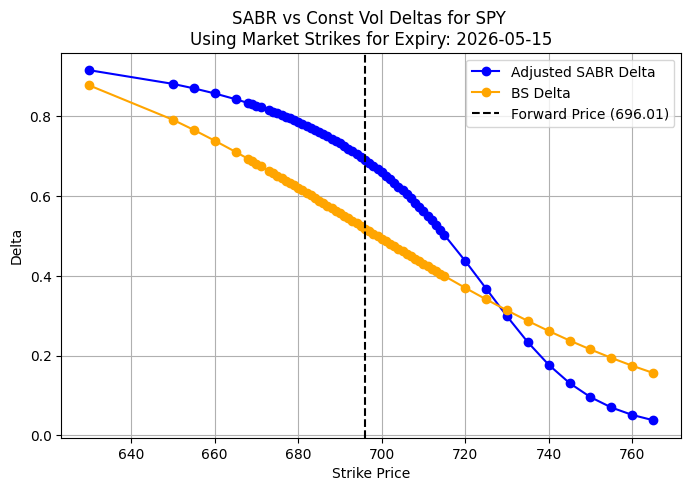

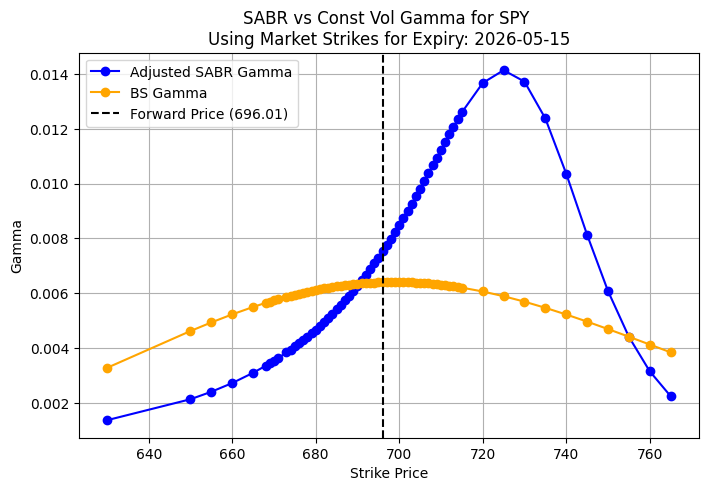

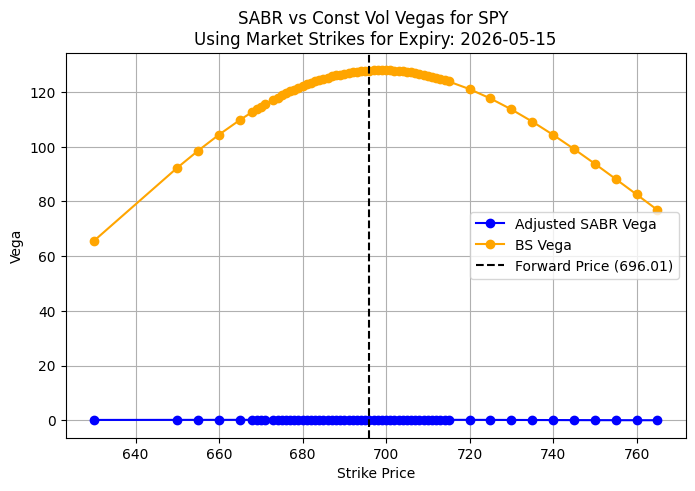

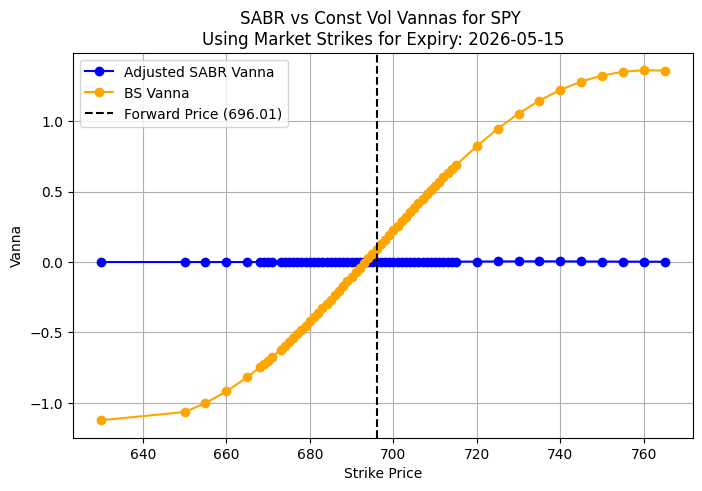

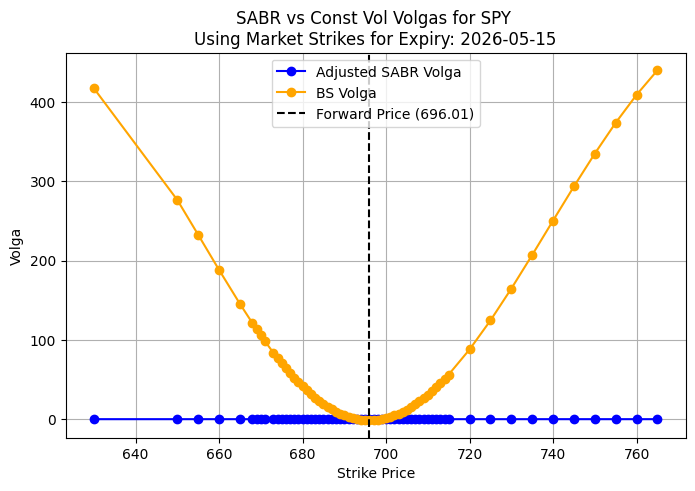

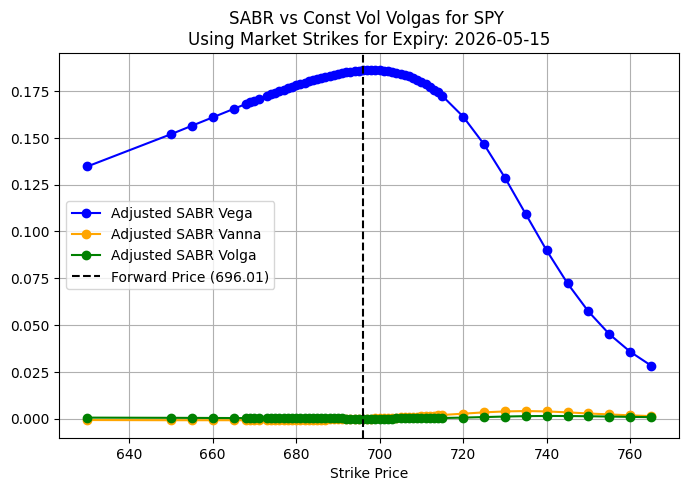

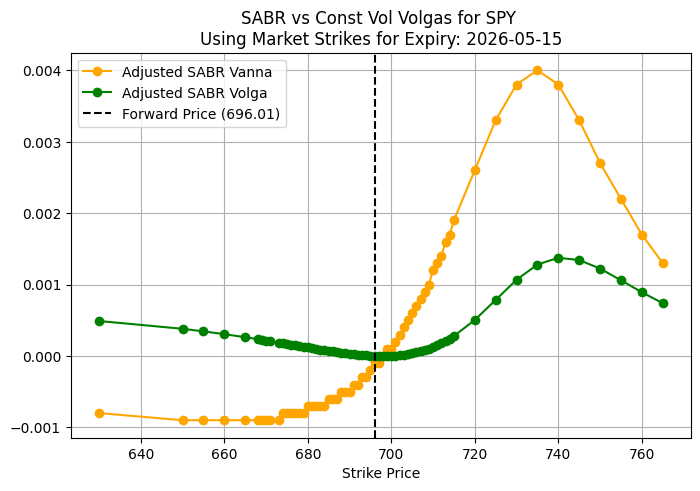

In [95]:
greeks = {
    'Delta': 'Deltas',
    'Gamma': 'Gamma',
    'Vega': 'Vegas',
    'Vanna': 'Vannas',
    'Volga': 'Volgas'
}

for greek, title_suffix in greeks.items():
    plt.figure(figsize=(8, 5))

    # Plot SABR and Black-Scholes data
    plt.plot(df_comparison['Strike'], df_comparison[f'Spot_SABR_{greek}'],
             label=f'Adjusted SABR {greek}', color='blue', marker='o')
    plt.plot(df_comparison['Strike'], df_comparison[f'BS_{greek}'],
             label=f'BS {greek}', color='orange', marker='o')
    plt.axvline(F, color='black', linestyle='--', label=f'Forward Price ({F:.2f})')
    plt.xlabel('Strike Price')
    plt.ylabel(greek)
    plt.legend()
    plt.title(f"SABR vs Const Vol {title_suffix} for {ticker_symbol} \n"
              f"Using Market Strikes for Expiry: {date}")
    plt.grid(True)

    plt.show()
    print('\n')

plt.figure(figsize=(8, 5))

# Plot SABR and Black-Scholes data
plt.plot(df_comparison['Strike'], df_comparison['Spot_SABR_Vega'],
          label='Adjusted SABR Vega', color='blue', marker='o')
plt.plot(df_comparison['Strike'], df_comparison['Spot_SABR_Vanna'],
          label='Adjusted SABR Vanna', color='orange', marker='o')
plt.plot(df_comparison['Strike'], df_comparison['Spot_SABR_Volga'],
          label='Adjusted SABR Volga', color='green', marker='o')
plt.axvline(F, color='black', linestyle='--', label=f'Forward Price ({F:.2f})')
plt.xlabel('Strike Price')
plt.legend()
plt.title(f"SABR vs Const Vol {title_suffix} for {ticker_symbol} \n"
          f"Using Market Strikes for Expiry: {date}")
plt.grid(True)
plt.show()
print('\n')

plt.figure(figsize=(8, 5))

# Plot SABR and Black-Scholes data
plt.plot(df_comparison['Strike'], df_comparison['Spot_SABR_Vanna'],
          label='Adjusted SABR Vanna', color='orange', marker='o')
plt.plot(df_comparison['Strike'], df_comparison['Spot_SABR_Volga'],
          label='Adjusted SABR Volga', color='green', marker='o')
plt.axvline(F, color='black', linestyle='--', label=f'Forward Price ({F:.2f})')
plt.xlabel('Strike Price')
plt.legend()
plt.title(f"SABR vs Const Vol {title_suffix} for {ticker_symbol} \n"
          f"Using Market Strikes for Expiry: {date}")
plt.grid(True)

plt.show()

Now we use the deltas to hedge against a sold call and backtest this hedging strategy.

In [96]:
# Initialization
t = 1
n_steps = 252
dt = t/n_steps
deltas = np.zeros(n_steps)
times = np.linspace(0,t, n_steps + 1)

# Data extraction
stock_data = yf.download(ticker_symbol, period = '2y', interval = '1d')
stock_path = np.array(stock_data['Close'][ticker_symbol].values[-n_steps-1:])
K = stock_path[0] # ATM Call just to begin with

# Generating deltas
for i in range(n_steps):
    s_metrics = sabr_greeks(stock_path[i]*np.exp((r - q)*((t-times)[i])), K, (t-times)[i], r, alpha_cal, beta_cal, rho_cal, nu_cal)
    deltas[i] = s_metrics['Delta'] * np.exp((r - q)*((t-times)[i]))

# Calculating the outcomes
stock_profits = (stock_path[1:n_steps+1] - stock_path[0:n_steps]*np.exp((r-q)*dt))*np.exp((q-r)*times[1:n_steps+1])*deltas
total_stock_profit = np.sum(stock_profits)
call_payout = np.maximum(stock_path[-1] - K, 0)*np.exp((q-r)*t)
call_profit_hedged = call_payout + total_stock_profit

# Display
print(f"Call payout: ${call_payout:.2f} \nStock profit: ${total_stock_profit:.2f}\nTotal profit of the hedging strategy: ${call_profit_hedged:.2f}.")

/tmp/ipython-input-819605836.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, period = '2y', interval = '1d')
[*********************100%***********************]  1 of 1 completed


Call payout: $99.25 
Stock profit: $36.14
Total profit of the hedging strategy: $135.39.


Further scope for improvement:
- Visualize volatility smiles from all expriries and use the better looking expiries to optimize the parameters (use a smaller sample from the sorted data if required).
- Analyze the comparison of Greeks from SABR and BS model.